In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
df=pd.read_csv("Data_clean.csv")
df.head()


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,is_fake
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,0
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,1
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,0
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,0
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,0


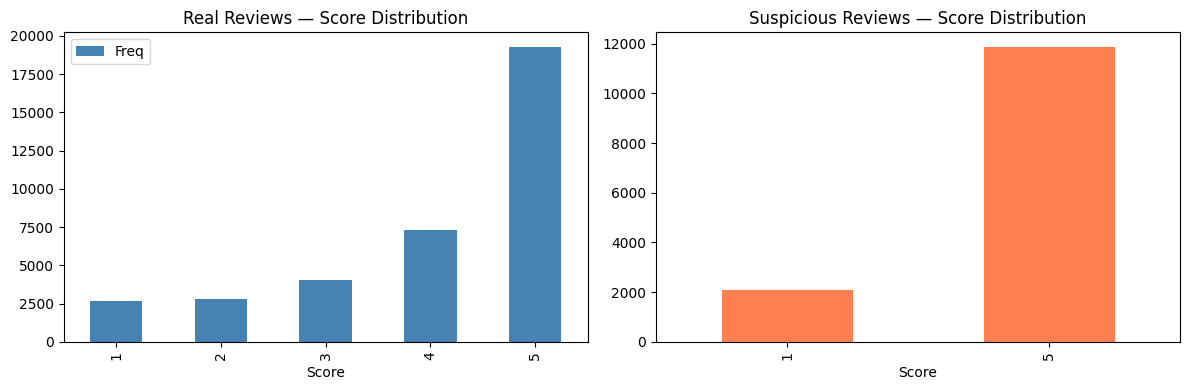

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
score_counts=(df[df['is_fake']==0]['Score'].value_counts().sort_index().reset_index())

score_counts.columns = ['Score', 'Freq']
# print(score_counts)
score_counts.plot(x='Score', y='Freq', kind='bar', ax=axes[0], color='steelblue', title='Real Reviews — Score Distribution')
df[df['is_fake']==1]['Score'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='coral', title='Suspicious Reviews — Score Distribution')
plt.tight_layout()
plt.savefig('score_distribution.png', dpi=150)
plt.show()


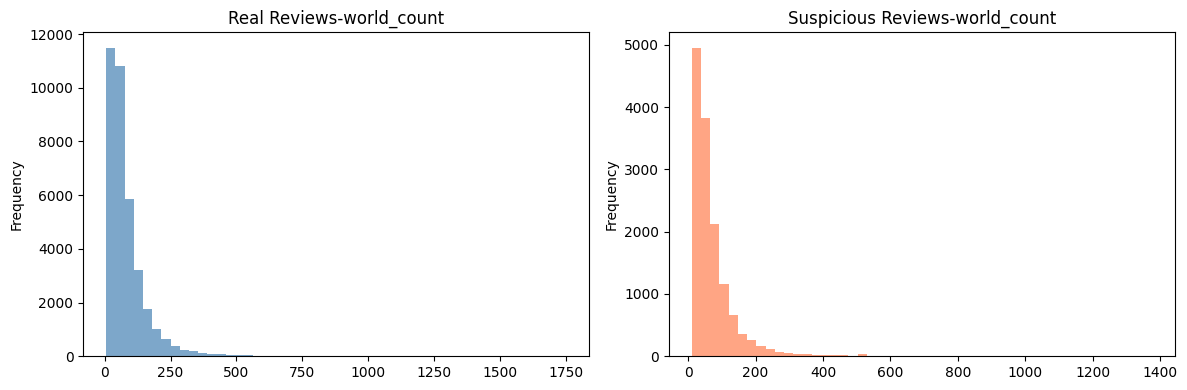

Avg word count — Real: 82.6
Avg word count — Fake: 71.2


<Figure size 640x480 with 0 Axes>

In [4]:
df['Text_len']= df['Text'].fillna('').str.len()
df['word_count']=df['Text'].fillna('').str.split().str.len()
fig,axes=plt.subplots(1,2,figsize=(12,4))
df[df['is_fake']==0]['word_count'].plot(kind='hist',bins =50, color = 'steelblue', ax=axes[0], title='Real Reviews-world_count',alpha=0.7)
df[df['is_fake']==1]['word_count'].plot(kind='hist',bins =50, color='coral', ax=axes[1], title='Suspicious Reviews-world_count',alpha=0.7)
plt.tight_layout()
plt.show()
plt.savefig('word_count_distribution.png', dpi=150)

print("Avg word count — Real:", df[df['is_fake']==0]['word_count'].mean().round(1))
print("Avg word count — Fake:", df[df['is_fake']==1]['word_count'].mean().round(1))
# print(df[df['word_count']>200]['word_count'].max())

In [11]:
print(df['HelpfulnessNumerator'],df['HelpfulnessDenominator'])

0        1
1        0
2        1
3        3
4        0
        ..
49995    0
49996    0
49997    0
49998    0
49999    0
Name: HelpfulnessNumerator, Length: 50000, dtype: int64 0        1
1        0
2        1
3        3
4        0
        ..
49995    0
49996    0
49997    0
49998    0
49999    0
Name: HelpfulnessDenominator, Length: 50000, dtype: int64


In [ ]:
df['helfulnessratio']=df['HelpfulnessNumerator']/df['HelpfulnessDenominator'].replace(0,1)
print('Avg Helpfulness Ratio- Real:', df[df['is_fake']==0]['helpfulnessratio'].mean().round(3))
print('Avg Helpfulness Ratio- Fake:', df[df['is_fake']==1]['helpfulnessratio'].mean().round(3))

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,is_fake,Text_len,word_count
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,0,263,48
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,1,190,31
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,0,509,94
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,0,219,41
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,0,140,27
5,6,B006K2ZZ7K,ADT0SRK1MGOEU,Twoapennything,0,0,4,1342051200,Nice Taffy,I got a wild hair for taffy and ordered this f...,0,416,72
6,7,B006K2ZZ7K,A1SP2KVKFXXRU1,David C. Sullivan,0,0,5,1340150400,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...,0,304,49
7,8,B006K2ZZ7K,A3JRGQVEQN31IQ,Pamela G. Williams,0,0,5,1336003200,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...,0,140,24
8,9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,1322006400,Yay Barley,Right now I'm mostly just sprouting this so my...,1,131,26
9,10,B00171APVA,A21BT40VZCCYT4,Carol A. Reed,0,0,5,1351209600,Healthy Dog Food,This is a very healthy dog food. Good for thei...,0,137,25
